# Amazon Sales Data Analysis
### A Beginner Exploratory Data Analysis Project


  



 

**Author:** Kunjum Jain

## 1. Introduction

### About the Dataset
This dataset contains product details from Amazon, including actual price, discounted price, discount percentage, ratings, and number of ratings. It provides a good view of how products are priced and how customers rate them.

### Project Objective
The main goal of this project is to perform Exploratory Data Analysis (EDA) on the Amazon Sales data to find meaningful insights such as:

- How discounts are distributed across products
- Relationship between discount and customer ratings
- Which price range of products gets better ratings
- Overall pricing and discount trends

 ## 2. Data Loading & Cleaning

### Loading the Dataset
First, we will load the Amazon sales dataset and look at its basic structure.

### Data Cleaning Steps
- Convert price related columns to numeric
- Remove unwanted symbols (₹, %, commas)
- Handle missing values if any
- Check data types


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette('Set2')

print("-----------------------------------------------Basic Structure of Amazon sales dataset----------------------------------------------")
print("\n")
df=pd.read_csv('Amazon.csv')
print(df)


print("\n --------------------------------------------Converting price related columns to numeric------------------------------------------")
print("\n")
df['discounted_price']=df['discounted_price'].str.replace('₹','').str.replace(',','')
df['discounted_price']=df['discounted_price'].astype(float)

df['actual_price']=df['actual_price'].str.replace('₹','').str.replace(',','')
df['actual_price']=df['actual_price'].astype(float)

df['discount_percentage']=df['discount_percentage'].str.replace('%','').str.replace('.','')
df['discount_percentage']=df['discount_percentage'].astype(float)


df['rating_count']=df['rating_count'].str.replace(',','')
df['rating_count']=df['rating_count'].astype(float)

df['rating']=df['rating'].str.replace(',','')
df['rating']=pd.to_numeric(df['rating'],errors='coerce')

print("\n")
print("\n -----------------------------------------------Handle missing values if any---------------------------------------------------")
print("\n")
print("\n------------------------------------------------Total NAN Values present-------------------------------------------------------")
print("\n")

summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Values (NaN)': df.isna().sum().values,
    'Missing %': (df.isna().sum().values / len(df) * 100).round(2)
})
print(summary)

print("\n")
print("\n----------------------------------------------------Cleaned Data---------------------------------------------------------------")
print("\n")

df=df.dropna(subset=['rating','rating_count'])
summary=pd.DataFrame({
    'column':df.columns,
    'Data Type':df.dtypes.values,
    'Missing Values (NAN)':df.isna().sum().values,
    'Missing %':(df.isna().sum().values/len(df)*100).round(2)
})
print(summary)

print("\n")
print("\n -----------------------------------------------Checking DataTypes-----------------------------------------------------------")
print("\n")

print(df.dtypes)


-----------------------------------------------Basic Structure of Amazon sales dataset----------------------------------------------


      product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

            

## 3. Exploratory Data Analysis
### Understanding the Data
Now that the dataset is clean, we will explore it to understand patterns, distributions, and relationships between variables.

### EDA Steps
- Summary statistics of numeric columns
- Distribution of prices and ratings
- Relationship between discounted price and actual price
- Correlation between numeric variables
- Category-wise analysis

--------------------------------------------Summary statistics of numeric columns--------------------------------------------------------


       discounted_price   actual_price  discount_percentage       rating  \
count       1462.000000    1462.000000          1462.000000  1462.000000   
mean        3129.981826    5453.087743            47.672367     4.096717   
std         6950.548042   10884.467444            21.613905     0.289497   
min           39.000000      39.000000             0.000000     2.000000   
25%          325.000000     800.000000            32.000000     4.000000   
50%          799.000000    1670.000000            50.000000     4.100000   
75%         1999.000000    4321.250000            63.000000     4.300000   
max        77990.000000  139900.000000            94.000000     5.000000   

        rating_count  
count    1462.000000  
mean    18307.376881  
std     42766.096572  
min         2.000000  
25%      1191.500000  
50%      5179.000000  
75%     17342.

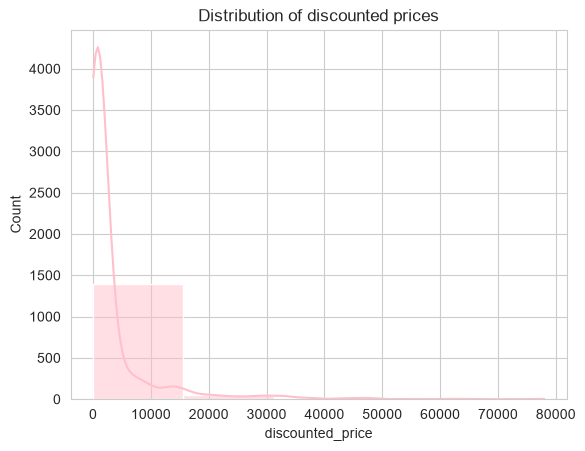

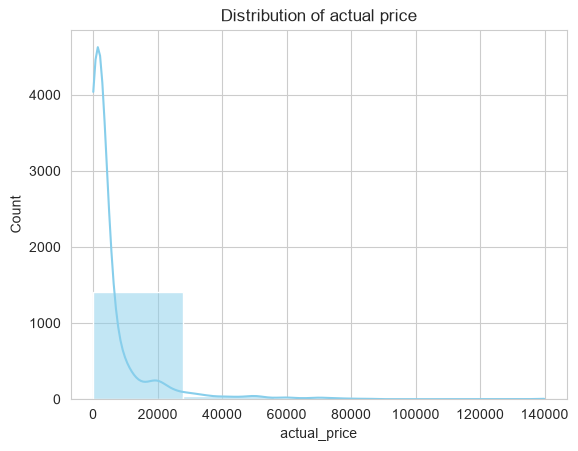

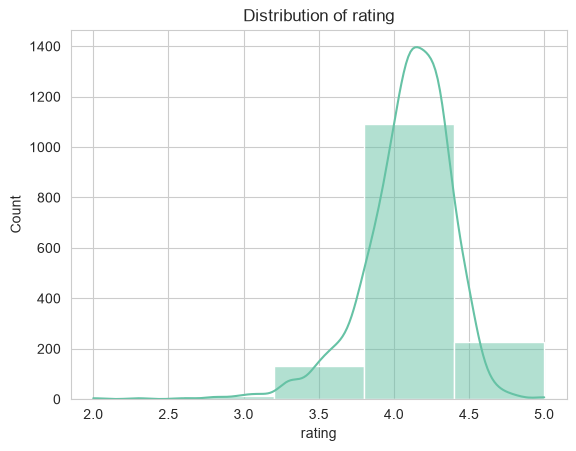

In [75]:
print("--------------------------------------------Summary statistics of numeric columns--------------------------------------------------------")
print("\n")

print(df.describe())

print("\n")
print("----------------------------------------------Distribution of prices and ratings---------------------------------------------------------")
print("\n")

sns.histplot(data=df,x='discounted_price',bins=5,kde=True,color='pink')
plt.title('Distribution of discounted prices')
plt.show()

sns.histplot(data=df,x='actual_price',bins=5,kde=True,color='skyblue')
plt.title('Distribution of actual price')
plt.show()

sns.histplot(data=df,x='rating',bins=5,kde=True)
plt.title('Distribution of rating')
plt.show()

print("\n")


**Insight:**
- Both discounted price and actual price are heavily right-skewed — most products are priced under ₹10,000-20,000, with a small number of expensive outliers pulling the range up to ₹80,000-140,000.
- The similar skew pattern in both price columns suggests discounts are applied proportionally across the price range, not just to expensive items.
- Ratings follow a roughly normal distribution centered around 4.0-4.5, indicating that most products receive consistently good feedback, with very few poorly-rated products.

--------------------------------------Relationship between discounted price and actual price---------------------------------------------




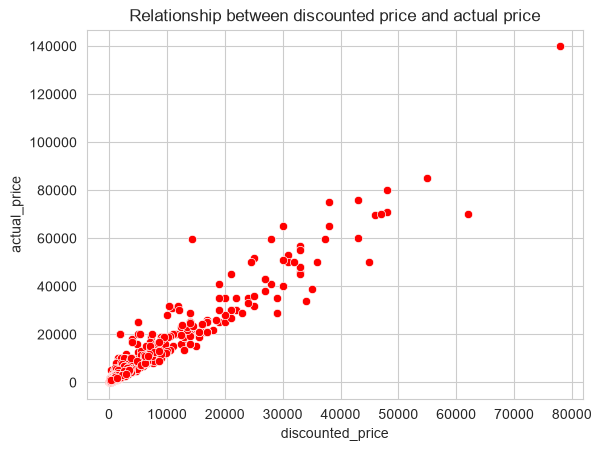

In [76]:
print("--------------------------------------Relationship between discounted price and actual price---------------------------------------------")
print("\n")

sns.scatterplot(data=df,x='discounted_price',y='actual_price',color= 'red')
plt.title('Relationship between discounted price and actual price')
plt.show()

**Insight:** There is a strong positive linear relationship between discounted price and actual price — as one increases, the other increases proportionally. This confirms that discounts are applied consistently as a percentage of the original price, rather than being random. A single high-value outlier (~₹80,000 discounted, ~₹140,000 actual) stands apart from the main cluster, representing the most expensive product in the dataset.

-----------------------------------------------Correlation between numeric variables-----------------------------------------------------




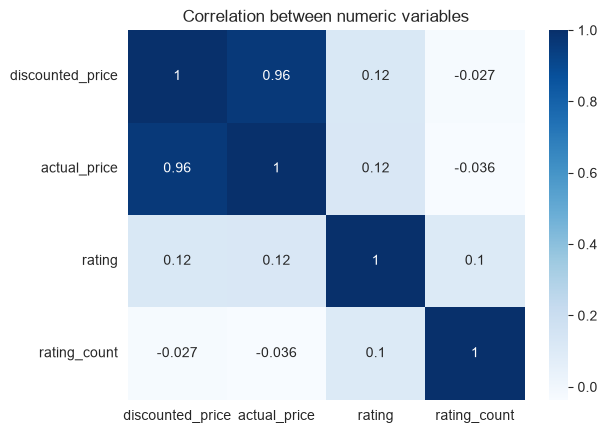

In [77]:
print("-----------------------------------------------Correlation between numeric variables-----------------------------------------------------")
print("\n")

correlation=df[['discounted_price','actual_price','rating','rating_count']].corr()
sns.heatmap(correlation,annot=True,cmap='Blues')
plt.title('Correlation between numeric variables')
plt.show()

print("\n")


**Insight:** The correlation heatmap confirms a very strong positive correlation (0.96) between discounted price and actual price, validating the pattern seen in the scatter plot. However, both price columns show almost no correlation with rating (0.12) or rating_count (-0.03), suggesting that price does not meaningfully influence customer satisfaction or product popularity. This indicates that lower-priced products can be just as well-rated and popular as expensive ones.

-----------------------------------------------Category-wise analysis--------------------------------------------------------------------


211




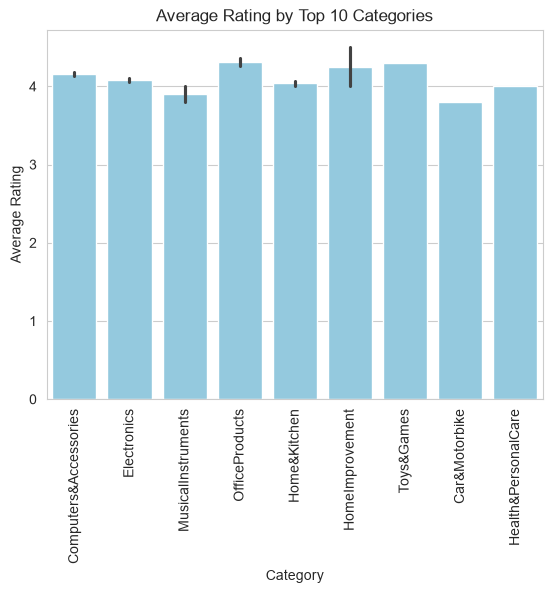

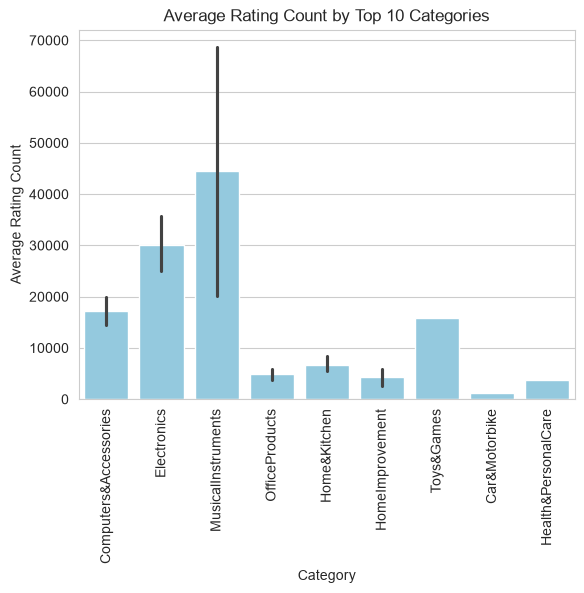

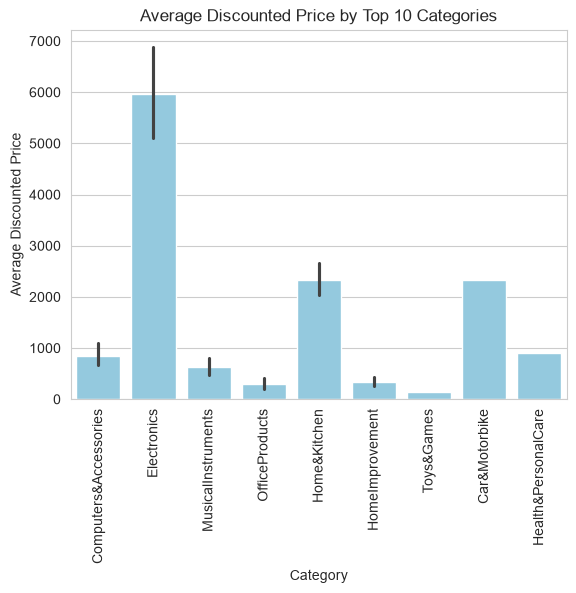

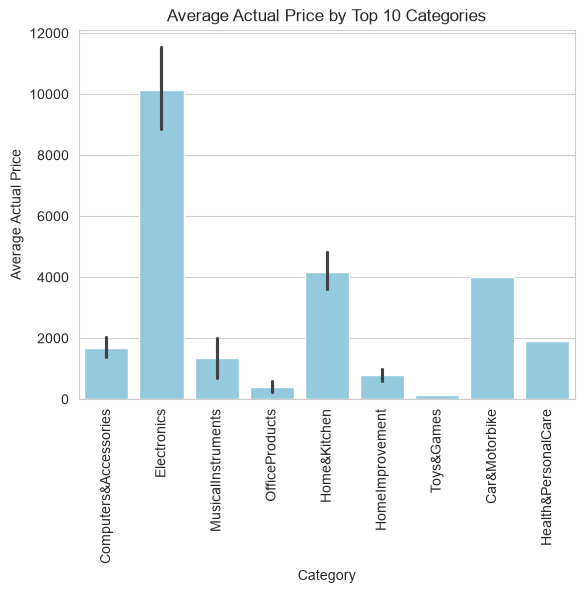

In [78]:
print("-----------------------------------------------Category-wise analysis--------------------------------------------------------------------")
print("\n")

#Number of categories
print(df['category'].nunique())

print("\n")

#Rating
top_categories = df['main_category'].value_counts().head(10).index
filtered_categories = df[df['main_category'].isin(top_categories)]

sns.barplot(data=filtered_categories, x='main_category', y='rating', estimator='mean', color='skyblue')
plt.title('Average Rating by Top 10 Categories')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)
plt.show()

print("\n")

#Rating_count
top_categories = df['main_category'].value_counts().head(10).index
filtered_categories = df[df['main_category'].isin(top_categories)]

sns.barplot(data=filtered_categories, x='main_category', y='rating_count', estimator='mean', color='skyblue')
plt.title('Average Rating Count by Top 10 Categories')
plt.xlabel('Category')
plt.ylabel('Average Rating Count')
plt.xticks(rotation=90)
plt.show()

print("\n")

#discounted_price
top_categories = df['main_category'].value_counts().head(10).index
filtered_categories = df[df['main_category'].isin(top_categories)]

sns.barplot(data=filtered_categories, x='main_category', y='discounted_price', estimator='mean', color='skyblue')
plt.title('Average Discounted Price by Top 10 Categories')
plt.xlabel('Category')
plt.ylabel('Average Discounted Price')
plt.xticks(rotation=90)
plt.show()

print("\n")

#actual_price
top_categories = df['main_category'].value_counts().head(10).index
filtered_categories = df[df['main_category'].isin(top_categories)]

sns.barplot(data=filtered_categories, x='main_category', y='actual_price', estimator='mean', color='skyblue')
plt.title('Average Actual Price by Top 10 Categories')
plt.xlabel('Category')
plt.ylabel('Average Actual Price')
plt.xticks(rotation=90)
plt.show()

**Insight:** 
- Average ratings remain fairly consistent (3.8-4.3) across all top categories, showing no major difference in customer satisfaction between product types.
- Musical Instruments has an unusually high average rating count, suggesting a few highly popular products are skewing the category average, rather than broad-based popularity.
- Electronics stands out as the most expensive category by a wide margin (both discounted and actual price), yet its average rating is not notably higher than cheaper categories — reinforcing the earlier finding that price does not strongly influence customer satisfaction.

## 4. Key Insights
### Summary of Findings
Based on the exploratory data analysis, here are the key takeaways from the Amazon sales dataset.

### Insights
- Discounted price and actual price show an extremely strong positive correlation (r = 0.96), confirming that discounts are applied proportionally rather than randomly across price ranges.
- Both price columns show almost no correlation with rating (0.12) or rating count (-0.03) — price does not meaningfully predict customer satisfaction or product popularity.
- Ratings remain fairly consistent (3.8-4.3) across all top product categories, showing no major difference in customer satisfaction between product types.
- Electronics is the most expensive category by a wide margin, yet its average rating is no higher than cheaper categories like Home&Kitchen — reinforcing that price doesn't drive satisfaction.
- Musical Instruments shows an unusually high average rating count, suggesting a few highly popular products are skewing the category average rather than broad-based popularity.
- Pricing is heavily right-skewed — most products fall under ₹10,000-20,000, with a small number of high-value outliers extending the range up to ₹80,000-140,000.
  
  ## 5. Visualizations
### Charts Used in This Analysis
The following visualizations were created to support the exploratory data analysis above:

- Histogram — Distribution of discounted prices and ratings
- Scatter Plot — Relationship between discounted price and actual price
- Heatmap — Correlation between numeric variables (price, rating, rating count)
- Box Plot — Spread and outliers in price and rating data
- Bar Plot — Average rating by product category
- Pair Plot — Combined relationships across discounted price, actual price, and rating

## 6. Conclusion
### Final Remarks
This analysis of the Amazon sales dataset helped us understand pricing patterns, customer ratings, and category-level trends through data cleaning, exploratory analysis, and visualization.

### Key Takeaways
- The dataset required significant cleaning (removing currency symbols, handling missing values) before it could be analyzed
- Pricing is heavily skewed toward lower-priced products, with a few high-value outliers
- Customer ratings remain consistently positive across most products, regardless of price
- Category-level analysis reveals which product categories dominate the dataset and drive customer engagement
- Next steps involve deeper statistical analysis using NumPy